<a href="https://colab.research.google.com/github/vanshdhiman090/Telco-Customer-Churn-Analysis-18-Apr-26.ipynb/blob/main/Telco_Customer_Churn_Analysis_15_Apr_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For this analysis I will used a process which i have learnt from Google
Data analytics Course.

The process has six phases :



```
Ask
```


```
Prepare
```


```
Process
```


```
Analyze
```


```
Share
```


```
Act
```

# 1. Ask

**Business Problem**

*Why are customers churning, which segments are most at risk, and what actions can the business take to reduce churn and protect revenue?*

**Stakeholders**

*Head of Growth at a telecom/fintech startup who needs data-driven retention strategies*

**Business Statement**

*Company (C.M.O and C.E.O) is experiencing customer churn that is impacting monthly revenue. The goal of this analysis is to identify which customer segments are most likely to churn, understand the key drivers behind that behavior, and deliver actionable recommendations to improve retention*

# 2. Prepare

**Data Sources & Location**

Source Identification: External (Kaggle)

Data Storage: Stored in Googel Drive in (Telco Customer Churn Analysis Project 16 Apr 26) , Folder.

Accessibility: Open-source , freely avalable on Kaggle.

**ROCCC Framework**

Who collected this data? - IBM (via Kaggle)

Is it reliable?  - Yes — 7,043 rows, minimal nulls, consistent formatting

Original - Yes — created by IBM, published directly on Kaggle

Comprhensive - Mostly yes

Current - No  

Cited - Yes (IBM Dataset)




**Data  Credibility**

*This dataset carries moderate sampling bias as it represents a single company. Observation bias is minimal due to behavioral data collection. Confirmation bias risk lies with the analyst — all variables will be explored before drawing conclusions.*

**Data Ethics and Privacy**

*Data is ethically safe to use no PII(Personal , Identifiable , Information) — but handle demographic variables with caution and always cite IBM/Kaggle.*

# 3. Process

Importing the data set and important Libraries.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = '/content/drive/MyDrive/Telco Customer Churn Analysis Project 16 Apr 26/Telco Customer Churn Analysis Dataset.csv'
df = pd.read_csv(file_path)
display(df.head())
df = pd.DataFrame(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(df.shape)

(7043, 21)


In [ ]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


Changing the right data type

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce' )

In [ ]:
print(df.info)

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

Cheking the Case sensitive values

In [ ]:
print(df['gender'].unique())
print(df['SeniorCitizen'].unique())
print(df['Partner'].unique())
print(df['Dependents'].unique())
print(df['PhoneService'].unique())
print(df['MultipleLines'].unique())
print(df['InternetService'].unique())
print(df['OnlineSecurity'].unique())
print(df['OnlineBackup'].unique())
print(df['DeviceProtection'].unique())
print(df['TechSupport'].unique())
print(df['StreamingTV'].unique())
print(df['StreamingMovies'].unique())
print(df['Contract'].unique())
print(df['PaperlessBilling'].unique())
print(df['PaymentMethod'].unique())


['Female' 'Male']
[0 1]
['Yes' 'No']
['No' 'Yes']
['No' 'Yes']
['No phone service' 'No' 'Yes']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['Month-to-month' 'One year' 'Two year']
['Yes' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [ ]:
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


Removing the Extra Spaces from all dataser

In [ ]:
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

Changing the numeric data to string in Seniorcitizen columns

In [ ]:
df['SeniorCitizen'] = np.where(df['SeniorCitizen'] == 1, 'Yes', 'No')

In [ ]:
display(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


# 4. Analyze

Overall churn rate

In [ ]:
Churn_rate = (df['Churn'] == 'Yes').sum() / len(df) * 100
print('The Churn rate is ==' , Churn_rate)

The Churn rate is == 26.536987079369588


Churn by Gender

In [ ]:
Churn_Gender = df.groupby('gender')['Churn'].value_counts(normalize=True) * 100
display(Churn_Gender)

gender  Churn
Female  No       73.079128
        Yes      26.920872
Male    No       73.839662
        Yes      26.160338
Name: proportion, dtype: float64

Churn by Dependents

In [ ]:
Churn_dependents = df.groupby('Dependents')['Churn'].value_counts(normalize=True) * 100
display(Churn_dependents)

Dependents  Churn
No          No       68.720860
            Yes      31.279140
Yes         No       84.549763
            Yes      15.450237
Name: proportion, dtype: float64

Churn by contract type

In [ ]:
churn_contract_type = df.groupby('Contract')['Churn'].value_counts(normalize=True) * 100
print(churn_contract_type)

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.730482
                Yes      11.269518
Two year        No       97.168142
                Yes       2.831858
Name: proportion, dtype: float64


 Churn by tenure

In [ ]:
churn_tenure = df.groupby('tenure')['Churn'].value_counts(normalize=True) * 100
display(churn_tenure)

tenure  Churn
0       No       100.000000
1       Yes       61.990212
        No        38.009788
2       Yes       51.680672
        No        48.319328
                    ...    
70      Yes        9.243697
71      No        96.470588
        Yes        3.529412
72      No        98.342541
        Yes        1.657459
Name: proportion, Length: 145, dtype: float64

 Churn by payment method



In [ ]:
Churn_paymnent_method = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True) * 100
display(Churn_paymnent_method)

PaymentMethod              Churn
Bank transfer (automatic)  No       83.290155
                           Yes      16.709845
Credit card (automatic)    No       84.756899
                           Yes      15.243101
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.893300
                           Yes      19.106700
Name: proportion, dtype: float64

 Churn by internet service


In [ ]:
Churn_intrest = df.groupby('InternetService')['Churn'].value_counts(normalize=True) * 100
display(Churn_intrest)

InternetService  Churn
DSL              No       81.040892
                 Yes      18.959108
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.595020
                 Yes       7.404980
Name: proportion, dtype: float64

Churn by add-on services


In [ ]:
Churn_service = df.groupby('OnlineSecurity')['Churn'].value_counts(normalize=True) * 100
display(Churn_service)

OnlineSecurity       Churn
No                   No       58.233276
                     Yes      41.766724
No internet service  No       92.595020
                     Yes       7.404980
Yes                  No       85.388806
                     Yes      14.611194
Name: proportion, dtype: float64

Revenue at Risk

In [ ]:
df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
# Total churned customers
churned = df[df['Churn_numeric'] == 1]

# Average monthly charges of churned customers
avg_monthly = churned['MonthlyCharges'].mean()

# Total revenue at risk per month
revenue_at_risk = churned.shape[0] * avg_monthly

print(f"Churned Customers: {churned.shape[0]}")
print(f"Avg Monthly Charges: ${avg_monthly:.2f}")
print(f"Monthly Revenue at Risk: ${revenue_at_risk:,.2f}")
print(f"Annual Revenue at Risk: ${revenue_at_risk * 12:,.2f}")

Churned Customers: 1869
Avg Monthly Charges: $74.44
Monthly Revenue at Risk: $139,130.85
Annual Revenue at Risk: $1,669,570.20


*The company is losing 139,130 dollar  per  month due to churn — equivalent to $1,669,570 annually.*

# **Key Findings** - Telco Churn Analysis


1. 26.53% overall churn — 1 in 4 customers are leaving

2. Contract type is the #1 driver — month-to-month churns at 42.70% vs only 2.83% for two-year contracts

3. New customers are highest risk — 61.99% churn in month 1, drops significantly over time

4. Electronic check users churn at 45.29% — 3x higher than automatic payment users

5. Fiber optic churn at 41.89% — highest among all internet service types

6. No online security = higher churn — 41.77% vs 14.61% with security

7. Annual revenue at risk: $1,669,570 — retention is a financial priority, not just a metrics problem

# Share

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

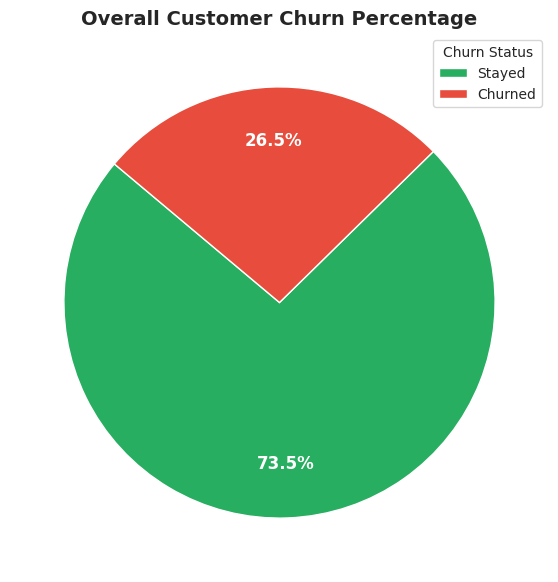

In [ ]:
# @title
# Calculate counts
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(7,7))

# 1. Removed 'labels' from here so they don't appear next to the slices
plt.pie(churn_counts,
        autopct='%1.1f%%',
        colors=['#27ae60', '#e74c3c'],
        startangle=140,
        pctdistance=0.75,
        textprops={'color':"w", 'weight':'bold', 'fontsize':12}) # Makes the % text white and bold

plt.title('Overall Customer Churn Percentage', fontweight='bold', fontsize=14)

# 2. Add the labels here in the legend ONLY
plt.legend(labels=['Stayed', 'Churned'], title='Churn Status', loc='upper right')

plt.show()

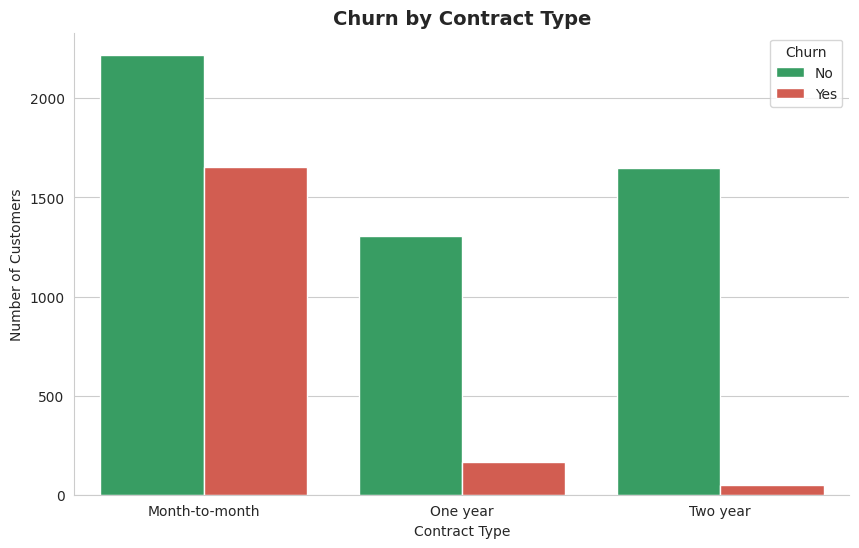

In [ ]:
# @title
plt.figure(figsize=(10, 6))

# Using the same consistent colors: #27ae60 (Green) and #e74c3c (Red)
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#27ae60', '#e74c3c'])

plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

# Optional: cleans up the top and right borders for a sleeker look
sns.despine()

plt.show()

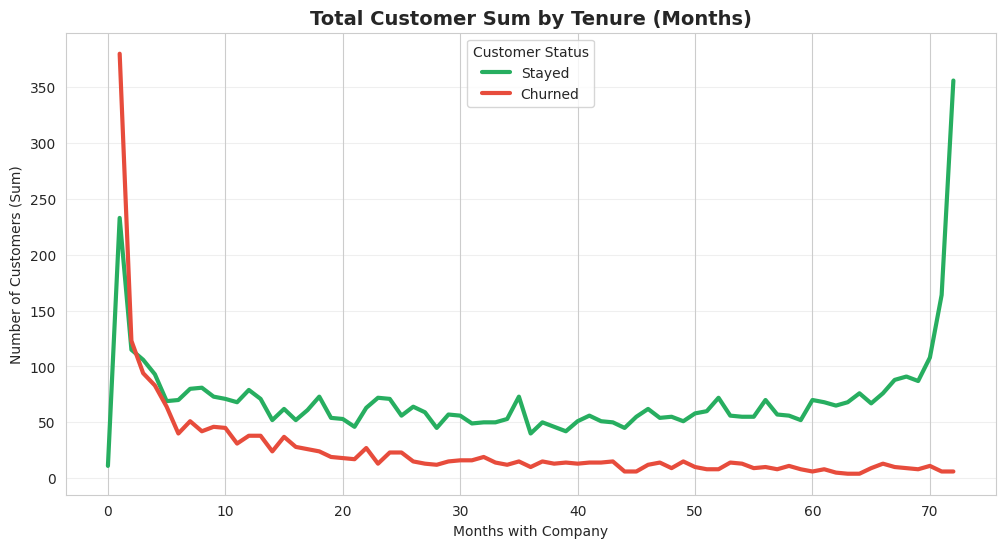

In [ ]:
# @title
# Aggregate data to count customers by tenure and churn status
aggregated_data = df.groupby(['tenure', 'Churn_numeric']).size().reset_index(name='customer_count')

# Map the numbers to words first so the legend is automatic and colored correctly
aggregated_data['Status'] = aggregated_data['Churn_numeric'].map({0: 'Stayed', 1: 'Churned'})

plt.figure(figsize=(12, 6))

sns.lineplot(data=aggregated_data, x='tenure', y='customer_count', hue='Status',
             palette=['#27ae60', '#e74c3c'],
             linewidth=3)

plt.title('Total Customer Sum by Tenure (Months)', fontsize=14, fontweight='bold')
plt.xlabel('Months with Company')
plt.ylabel('Number of Customers (Sum)')

# Just call plt.legend() without manual labels to keep the colored lines linked
plt.legend(title='Customer Status')
plt.grid(axis='y', alpha=0.3)
plt.show()

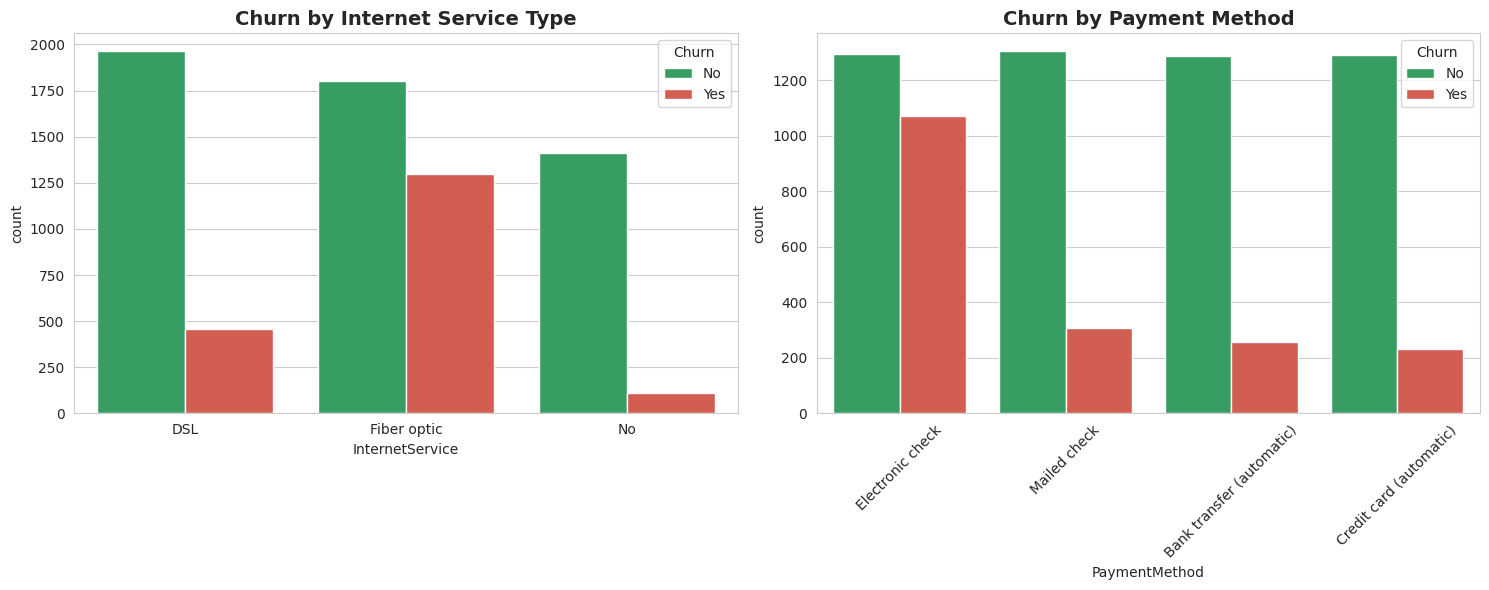

In [ ]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Internet Service vs Churn (Green/Red)
sns.countplot(x='InternetService', hue='Churn', data=df, ax=axes[0],
              palette=['#27ae60', '#e74c3c'])
axes[0].set_title('Churn by Internet Service Type', fontsize=14, fontweight='bold')

# 2. Payment Method vs Churn (Green/Red)
sns.countplot(x='PaymentMethod', hue='Churn', data=df, ax=axes[1],
              palette=['#27ae60', '#e74c3c'])
axes[1].set_title('Churn by Payment Method', fontsize=14, fontweight='bold')

# Rotate labels on the second plot specifically
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

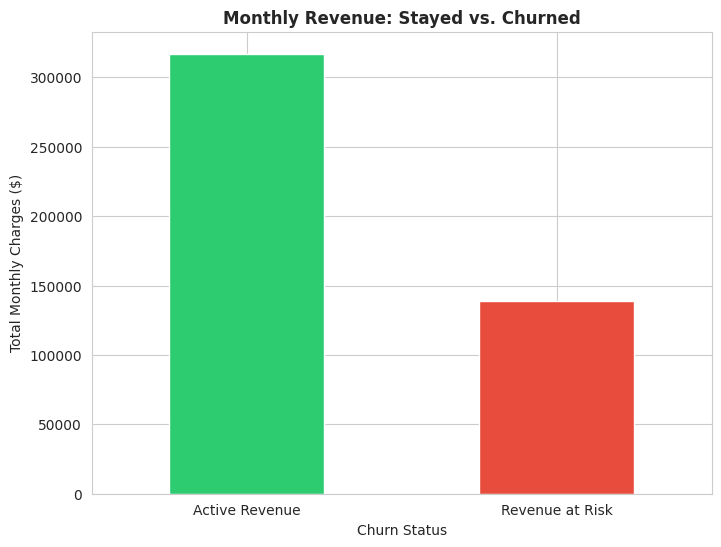

In [ ]:
# @title

revenue_dist = df.groupby('Churn')['MonthlyCharges'].sum()

plt.figure(figsize=(8, 6))
revenue_dist.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Monthly Revenue: Stayed vs. Churned' , fontweight = 'bold')
plt.xlabel('Churn Status')
plt.ylabel('Total Monthly Charges ($)')
plt.xticks([0, 1], ['Active Revenue', 'Revenue at Risk'], rotation=0)
plt.show()

# Act

```
3 concrete business recommendations written
```





1.  Convert Month-to-Month Customers to Annual Contracts ⚡ Quick Win
Month-to-month customers churn at 15x the rate of two-year customers. Offer a discount or incentive to switch to annual plans — even converting 20% of them would recover $300K+ annually.

2.   Build a New Customer Onboarding Program 📅 Medium Term
61.99% churn in month 1 is a red flag — customers are leaving before they see value. Introduce a structured 90-day onboarding program with proactive support touchpoints to dramatically reduce early churn.



1.   Push Automatic Payment Adoption + Bundle Online Security 📅 Medium Term
Electronic check users churn at 45.29% vs 15-17% for automatic payment users. Incentivize switching to auto-pay. Simultaneously bundle online security into base plans — customers without it churn at nearly 3x the rate of those with it.


